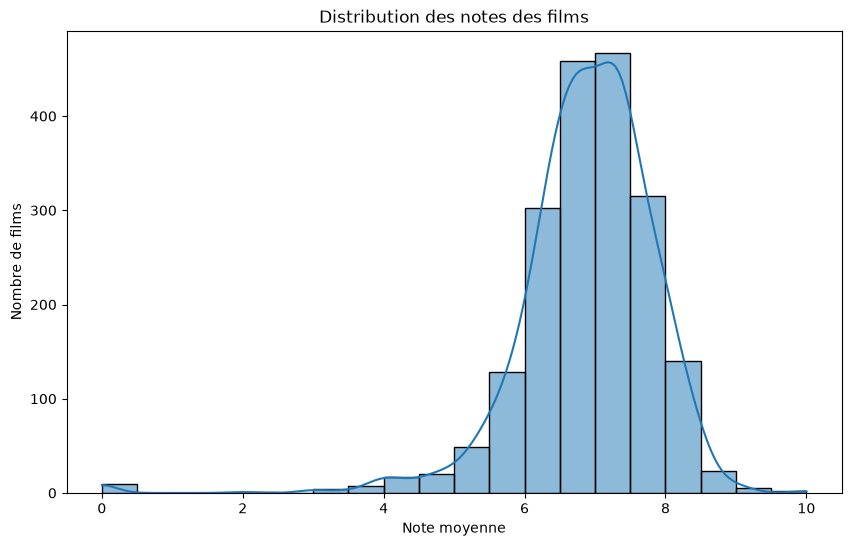

In [134]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.analysis import getAllMovies

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


movies = list(getAllMovies())
df = pd.DataFrame(movies)

plt.figure(figsize=(10, 6))

# notes des films
sns.histplot(
    data=df,
    x="vote_average",
    bins=20,
    kde=True
)

plt.title("Distribution des notes des films")
plt.xlabel("Note moyenne")
plt.ylabel("Nombre de films")

plt.show()

    



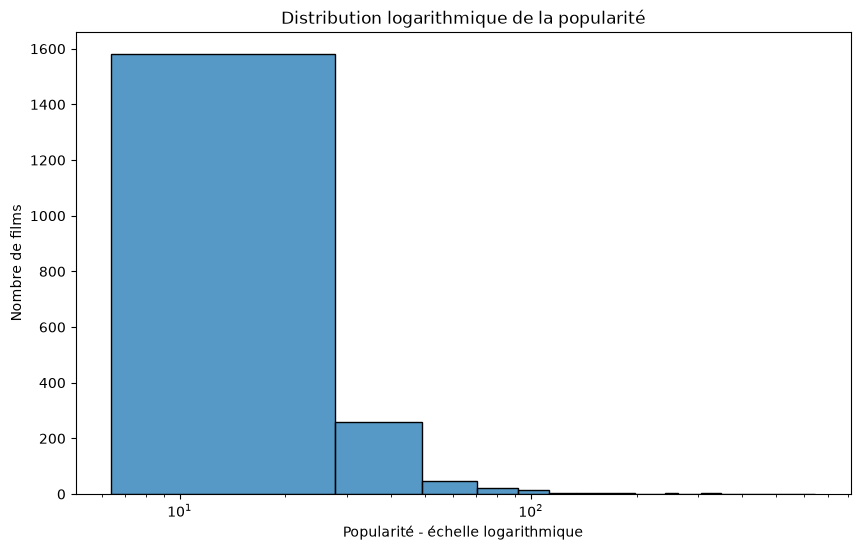

In [135]:
# la popularite des films
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="popularity",
    bins=30
)
plt.xscale("log")

plt.title("Distribution logarithmique de la popularité")
plt.xlabel("Popularité - échelle logarithmique")
plt.ylabel("Nombre de films")

plt.show()

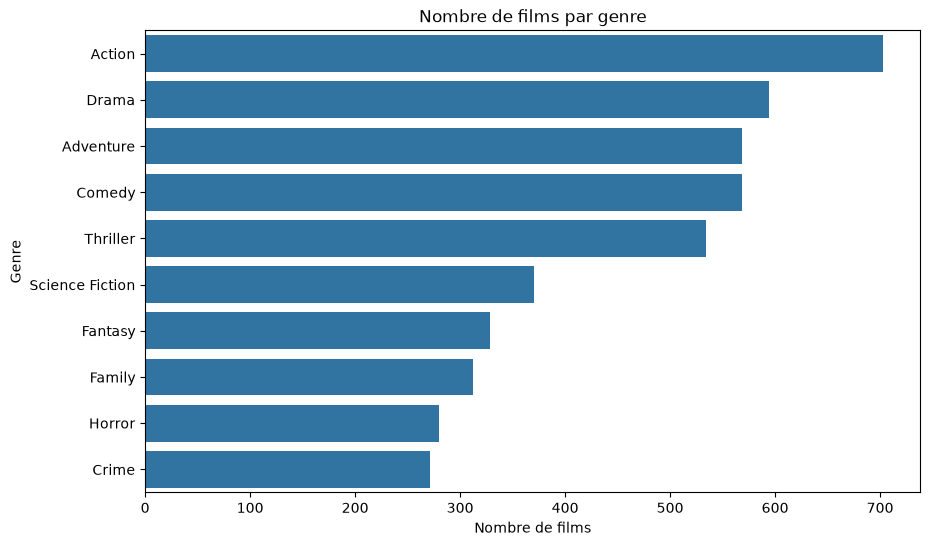

In [136]:
df_genres = df.explode("genres")

genre_counts = (
    df_genres["genres"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Nombre de films par genre")
plt.xlabel("Nombre de films")
plt.ylabel("Genre")

plt.show()

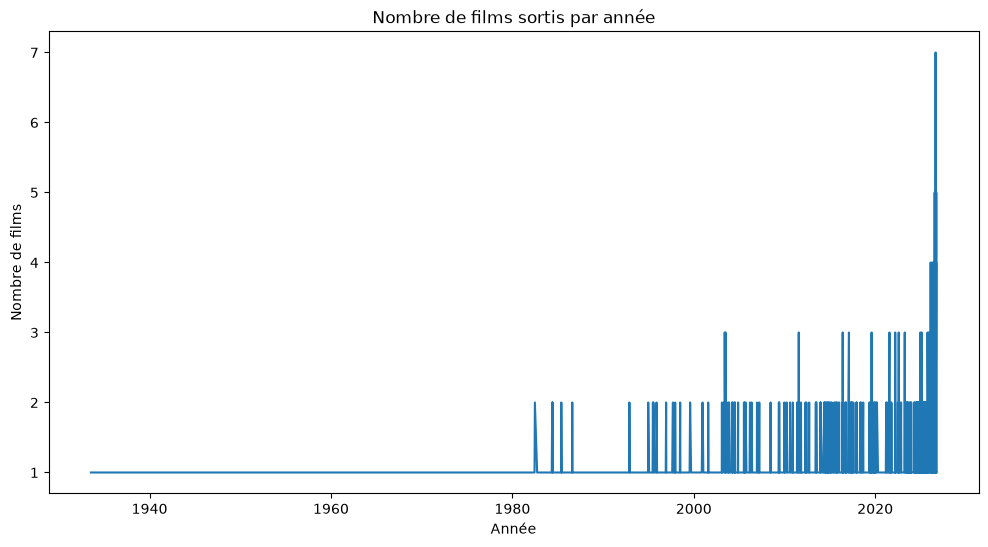

In [137]:
movies_by_date = (
    df.groupby("release_date")
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=movies_by_date,
    x="release_date",
    y="count"
)

plt.title("Nombre de films sortis par année")
plt.xlabel("Année")
plt.ylabel("Nombre de films")

plt.show()

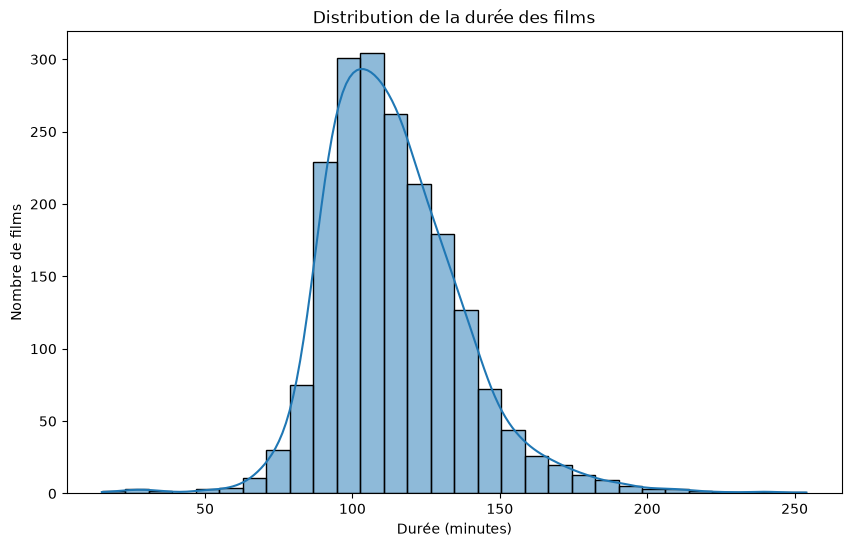

In [138]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="runtime",
    bins=30,
    kde=True
)

plt.title("Distribution de la durée des films")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")

plt.show()

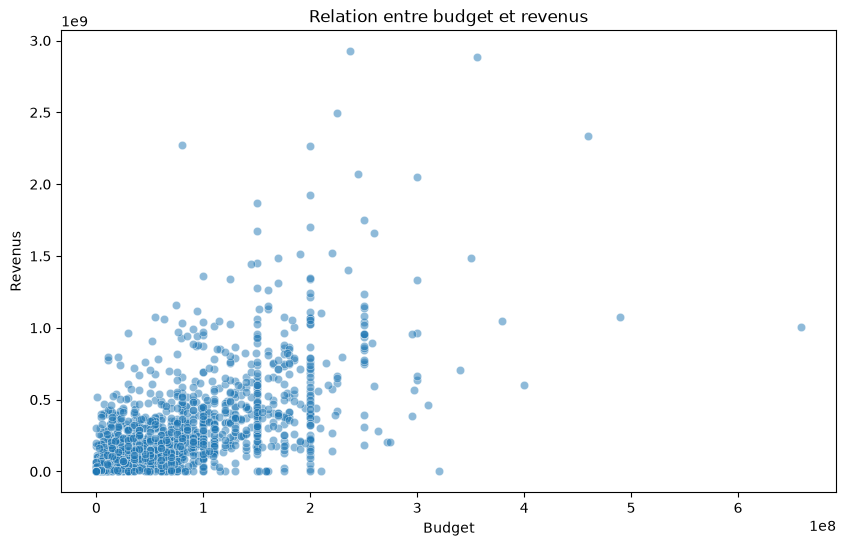

In [139]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    alpha=0.5
)

plt.title("Relation entre budget et revenus")
plt.xlabel("Budget")
plt.ylabel("Revenus")

plt.show()

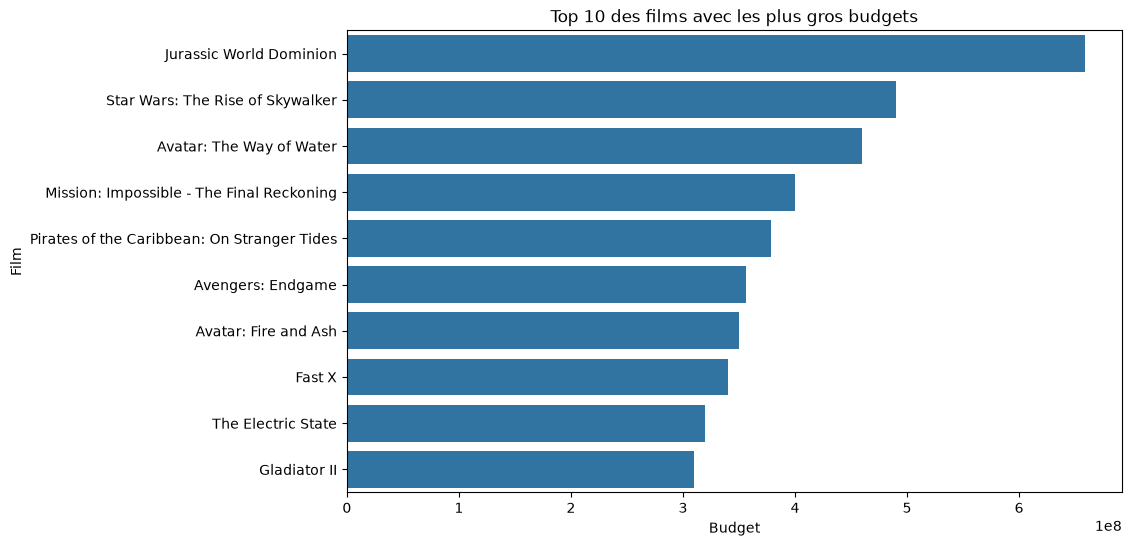

In [140]:
top_budget = (
    df.nlargest(10, "budget")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_budget,
    x="budget",
    y="title"
)

plt.title("Top 10 des films avec les plus gros budgets")
plt.xlabel("Budget")
plt.ylabel("Film")

plt.show()

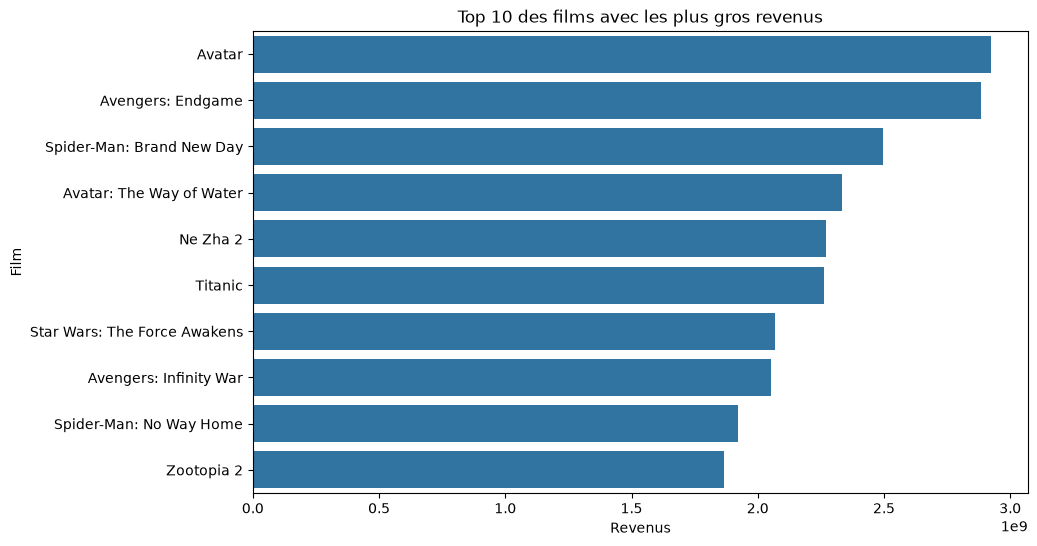

In [141]:
top_revenue = (
    df.nlargest(10, "revenue")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue,
    x="revenue",
    y="title"
)

plt.title("Top 10 des films avec les plus gros revenus")
plt.xlabel("Revenus")
plt.ylabel("Film")

plt.show()

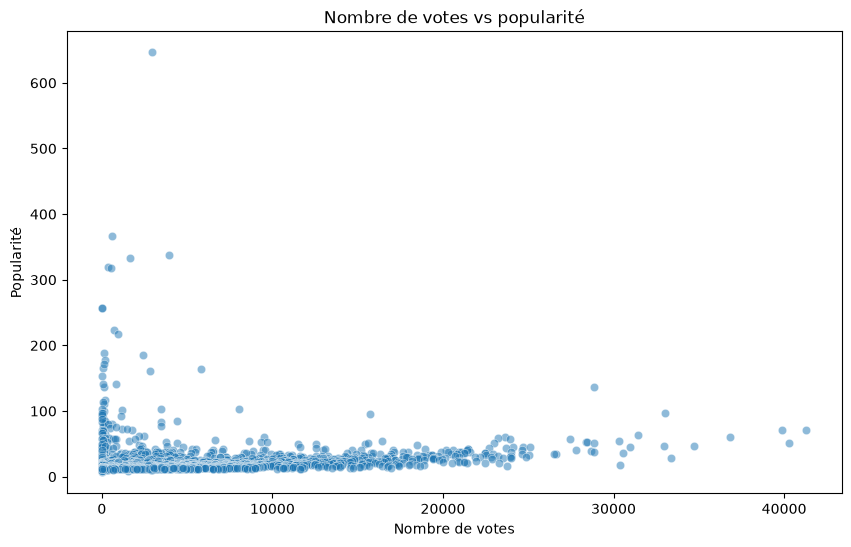

In [142]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="vote_count",
    y="popularity",
    alpha=0.5
)

plt.title("Nombre de votes vs popularité")
plt.xlabel("Nombre de votes")
plt.ylabel("Popularité")

plt.show()

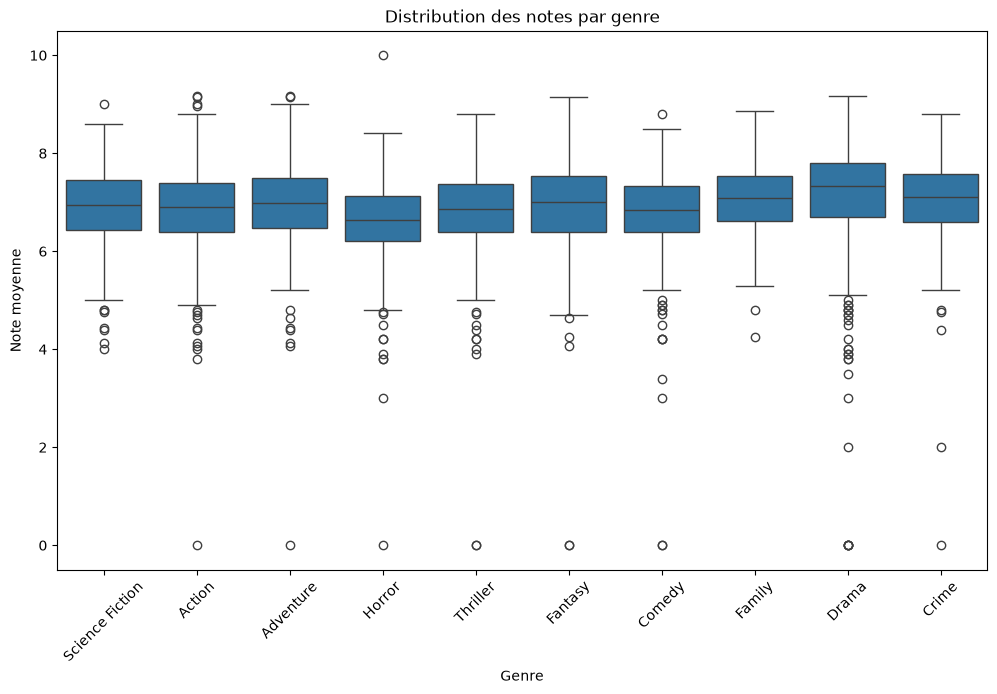

In [143]:
df_genres = df.explode("genres")

top_genres = (
    df_genres["genres"]
    .value_counts()
    .head(10)
    .index
)

df_top_genres = df_genres[
    df_genres["genres"].isin(top_genres)
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_top_genres,
    x="genres",
    y="vote_average"
)

plt.xticks(rotation=45)

plt.title("Distribution des notes par genre")
plt.xlabel("Genre")
plt.ylabel("Note moyenne")

plt.show()

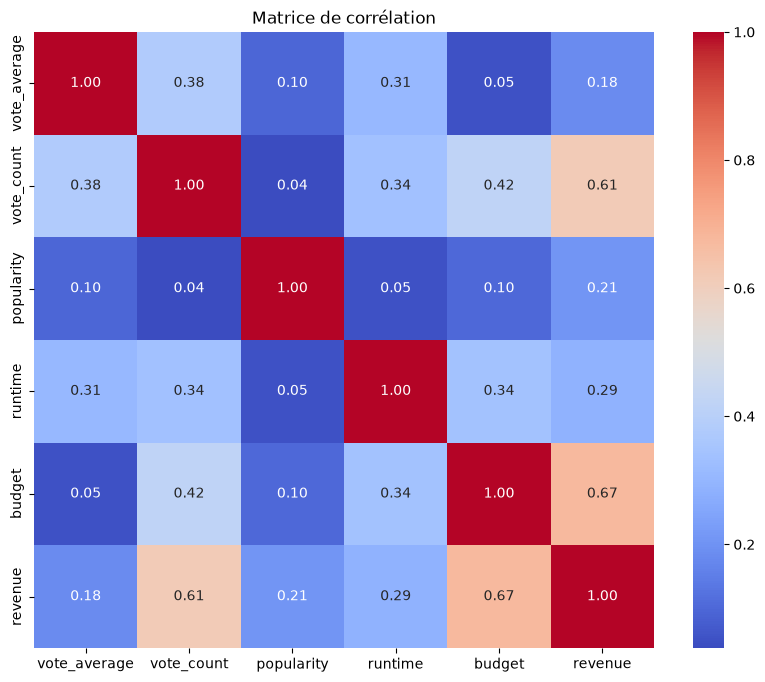

In [144]:
numeric_cols = [
    "vote_average",
    "vote_count",
    "popularity",
    "runtime",
    "budget",
    "revenue"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

In [145]:
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_decade"] = (df["release_year"] // 10) * 10

df["num_genres"] = df["genres"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

def categorize_runtime(runtime):
    if pd.isna(runtime):
        return "Unknown"
    elif runtime < 90:
        return "Court"
    elif runtime < 120:
        return "Moyen"
    elif runtime < 150:
        return "Long"
    else:
        return "Très long"

df["runtime_category"] = df["runtime"].apply(categorize_runtime)

def categorize_popularity(x):
    if x < 10:
        return "Faible"
    elif x < 50:
        return "Moyenne"
    elif x < 100:
        return "Élevée"
    else:
        return "Très élevée"

df["popularity_category"] = df["popularity"].apply(
    categorize_popularity
)

def categorize_rating(x):
    if x < 5:
        return "Faible"
    elif x < 7:
        return "Moyenne"
    elif x < 8:
        return "Bonne"
    else:
        return "Excellente"

df["rating_category"] = df["vote_average"].apply(
    categorize_rating
)

print(df.dtypes)

movie_id                        int64
budget                          int64
genres                         object
keywords                       object
original_language                 str
overview                          str
popularity                    float64
release_date           datetime64[us]
revenue                         int64
runtime                         int64
title                             str
vote_average                  float64
vote_count                      int64
release_year                    int32
release_month                   int32
release_decade                  int32
num_genres                      int64
runtime_category                  str
popularity_category               str
rating_category                   str
dtype: object


In [146]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

df["overview"] = df["overview"].fillna("")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["overview_clean"] = df["overview"].apply(clean_text)

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=1000,
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(df["overview_clean"])


print("Dimensions :", X_tfidf.shape)


terms = vectorizer.get_feature_names_out()
print("Nombre de termes :", len(terms))

scores = np.asarray(X_tfidf.sum(axis=0)).ravel()

top_indices = scores.argsort()[::-1][:20]

for i in top_indices:
    print(terms[i], scores[i])

Dimensions : (1947, 1000)
Nombre de termes : 1000
world 50.87653115760834
life 48.22254341160451
new 47.95348131390855
family 42.03939053963374
young 39.791906226403995
man 32.51146578355415
finds 27.299676526132707
love 27.185118858495187
mysterious 25.94134152749471
home 25.499195854884597
friends 25.333307976026983
war 24.883308690050924
years 24.421293604313927
old 24.34634277792334
time 24.215464853782553
help 23.78169363764597
story 23.582726064460857
group 22.453221643454725
father 21.87847188132816
lives 21.810972642823987


In [147]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# print(df["vote_count"].describe())

threshold = df["vote_count"].median()

df["high_engagement"] = (
    df["vote_count"] >= threshold
).astype(int)

# print(df["high_engagement"].value_counts())
numeric_features = [
    "popularity",
    "runtime",
    "release_year",
    "vote_average",
    "budget",
    "revenue"
]

X = df[
    [
        "popularity",
        "runtime",
        "release_year",
        "vote_average",
        "budget",
        "revenue"
    ]
]

y = df["high_engagement"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        )
    ]
)

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [149]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LinearSVC(
            random_state=42
        )
    )
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

y_score_svm = svm_model.decision_function(X_test)

In [150]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(name, y_test, y_pred, y_score):
    print(f"\n===== {name} =====")

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_score))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

evaluate_model(
    "Linear SVM",
    y_test,
    y_pred_svm,
    y_score_svm
)


===== Logistic Regression =====
Accuracy : 0.8
Precision: 0.7969543147208121
Recall   : 0.8051282051282052
F1-score : 0.8010204081632653
ROC-AUC  : 0.8730834976988823

Confusion Matrix:
[[155  40]
 [ 38 157]]

===== Random Forest =====
Accuracy : 0.8948717948717949
Precision: 0.8737864077669902
Recall   : 0.9230769230769231
F1-score : 0.8977556109725686
ROC-AUC  : 0.9583826429980276

Confusion Matrix:
[[169  26]
 [ 15 180]]

===== Linear SVM =====
Accuracy : 0.7974358974358975
Precision: 0.7929292929292929
Recall   : 0.8051282051282052
F1-score : 0.7989821882951654
ROC-AUC  : 0.8704536489151874

Confusion Matrix:
[[154  41]
 [ 38 157]]


In [151]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import joblib
from pathlib import Path

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"]
        }
    ),

    "Linear SVM": (
        LinearSVC(random_state=42),
        {
            "C": [0.01, 0.1, 1, 10]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    )
}

for name, (model, param_grid) in models.items():

    print("\n================================")
    print(name)
    print("================================")

    # Recherche des meilleurs hyperparamètres
    grid = GridSearchCV(
        model,
        param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X, y)

    best_model = grid.best_estimator_

    print("Meilleurs paramètres :", grid.best_params_)

    # Évaluation du meilleur modèle
    scores = cross_validate(
        best_model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    )

    print("Accuracy :", scores["test_accuracy"].mean())
    print("Precision:", scores["test_precision"].mean())
    print("Recall   :", scores["test_recall"].mean())
    print("F1-score :", scores["test_f1"].mean())
    print("ROC-AUC  :", scores["test_roc_auc"].mean())


PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "high_engagement_model.joblib"

joblib.dump(best_model, MODEL_PATH)



Logistic Regression
Meilleurs paramètres : {'C': 0.01, 'solver': 'liblinear'}
Accuracy : 0.6887324500692109
Precision: 0.6209012220689896
Recall   : 0.9733333333333334
F1-score : 0.7580968117655127
ROC-AUC  : 0.8434461863803657

Linear SVM
Meilleurs paramètres : {'C': 0.01}
Accuracy : 0.6645929734361611
Precision: 0.6014950747401914
Recall   : 0.9805128205128206
F1-score : 0.7455283836084688
ROC-AUC  : 0.8452896019303633

Random Forest
Meilleurs paramètres : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy : 0.8695273877793157
Precision: 0.8587361028967726
Recall   : 0.885128205128205
F1-score : 0.8714306068425841
ROC-AUC  : 0.9531485661223964


['c:\\Users\\ycode\\Documents\\workespace\\Movie Intelligence\\models\\high_engagement_model.joblib']

In [152]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Nombre de features à conserver
selector = SelectKBest(
    score_func=chi2,
    k=500
)

X_selected = selector.fit_transform(
    X_tfidf,
    y
)

print("Dimension originale :", X_tfidf.shape)
print("Dimension après sélection :", X_selected.shape)


# Tester plusieurs K
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_selected)

    score = silhouette_score(
        X_selected,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")



# Meilleur K
best_k = k_values[
    silhouette_scores.index(max(silhouette_scores))
]

print("Meilleur K :", best_k)
print(
    "Meilleur Silhouette Score :",
    max(silhouette_scores)
)

Dimension originale : (1947, 1000)
Dimension après sélection : (1947, 500)
K = 2 | Silhouette Score = 0.0112
K = 3 | Silhouette Score = 0.0087
K = 4 | Silhouette Score = 0.0098
K = 5 | Silhouette Score = 0.0141
K = 6 | Silhouette Score = 0.0161
K = 7 | Silhouette Score = 0.0118
K = 8 | Silhouette Score = 0.0168
K = 9 | Silhouette Score = 0.0082
K = 10 | Silhouette Score = 0.0173
Meilleur K : 10
Meilleur Silhouette Score : 0.0173211715457251


In [153]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Réduction de dimension
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_svd = svd.fit_transform(X_tfidf)

print("Dimension originale :", X_tfidf.shape)
print("Dimension après SVD :", X_svd.shape)

# Tester plusieurs K
k_values = range(2, 11)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_svd)

    score = silhouette_score(
        X_svd,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k} | "
        f"Silhouette Score = {score:.4f}"
    )



# Meilleur K
best_k = k_values[
    silhouette_scores.index(max(silhouette_scores))
]

print("\nMeilleur K :", best_k)
print(
    "Meilleur Silhouette Score :",
    max(silhouette_scores)
)

Dimension originale : (1947, 1000)
Dimension après SVD : (1947, 100)
K = 2 | Silhouette Score = 0.0273
K = 3 | Silhouette Score = 0.0278
K = 4 | Silhouette Score = 0.0296
K = 5 | Silhouette Score = 0.0246
K = 6 | Silhouette Score = 0.0284
K = 7 | Silhouette Score = 0.0380
K = 8 | Silhouette Score = 0.0366
K = 9 | Silhouette Score = 0.0378
K = 10 | Silhouette Score = 0.0411

Meilleur K : 10
Meilleur Silhouette Score : 0.04110420840632473


In [154]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

components_values = [2, 3, 5, 8, 10, 12, 15, 18, 20]

results = []

for n_components in components_values:

    svd = TruncatedSVD(
        n_components=n_components,
        random_state=42
    )

    X_reduced = svd.fit_transform(X_tfidf)

    best_score = -1
    best_k = None

    for k in range(2, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X_reduced)

        score = silhouette_score(
            X_reduced,
            labels
        )

        if score > best_score:
            best_score = score
            best_k = k

    results.append({
        "n_components": n_components,
        "best_k": best_k,
        "silhouette": best_score
    })

    print(
        f"SVD={n_components} | "
        f"Best K={best_k} | "
        f"Silhouette={best_score:.4f}"
    )

SVD=2 | Best K=2 | Silhouette=0.3987
SVD=3 | Best K=3 | Silhouette=0.3171
SVD=5 | Best K=2 | Silhouette=0.4607
SVD=8 | Best K=2 | Silhouette=0.4396
SVD=10 | Best K=2 | Silhouette=0.3885
SVD=12 | Best K=9 | Silhouette=0.2038
SVD=15 | Best K=10 | Silhouette=0.1726
SVD=18 | Best K=9 | Silhouette=0.1403
SVD=20 | Best K=9 | Silhouette=0.1428


cluster
1    1054
0     893
Name: count, dtype: int64
Shape avant : (1947, 1000)
Shape après : (1947, 2)


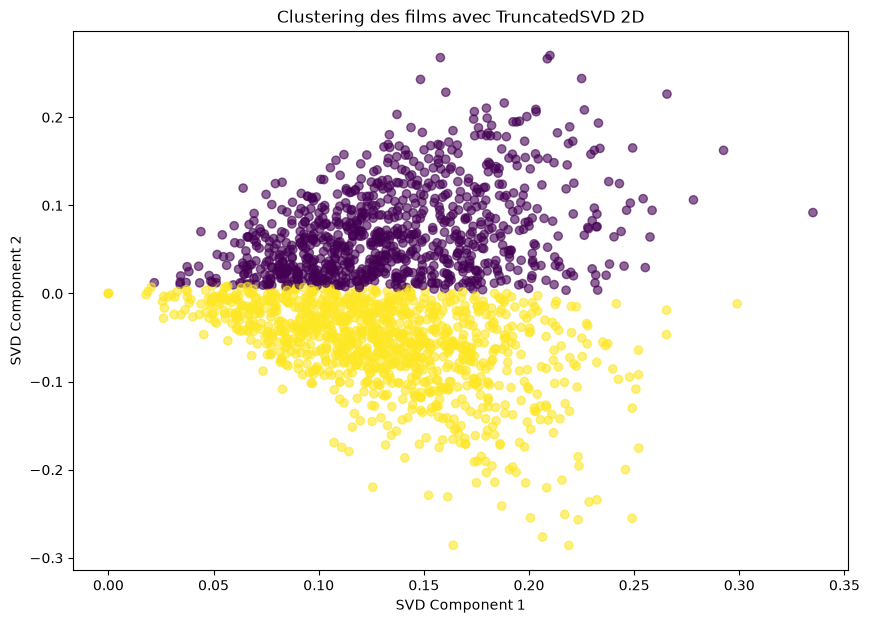

In [158]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_svd = svd.fit_transform(X_tfidf)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_svd)

df["cluster"] = labels

print(df["cluster"].value_counts())

print("Shape avant :", X_tfidf.shape)
print("Shape après :", X_svd.shape)


plt.figure(figsize=(10, 7))

plt.scatter(
    X_svd[:, 0],
    X_svd[:, 1],
    c=labels,
    alpha=0.6
)

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("Clustering des films avec TruncatedSVD 2D")

plt.show()

In [157]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("svd", TruncatedSVD(n_components=2, random_state=42)),
    ("kmeans", KMeans(n_clusters=2, random_state=42, n_init=20)),
])

labels = pipeline.fit_predict(df["overview_clean"]) 

PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "pipeline_clustering.joblib"

joblib.dump(pipeline, MODEL_PATH)

['c:\\Users\\ycode\\Documents\\workespace\\Movie Intelligence\\models\\pipeline_clustering.joblib']